In [1]:
import pandas as pd
import numpy as np
import os
import time
import json
import requests
import re

# Groq API setup
GROQ_KEY = "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"
GROQ_URL = "https://api.groq.com/openai/v1/chat/completions"

def ask_llm(prompt, temperature=0.1):
    resp = requests.post(
        GROQ_URL,
        json={
            "model": "llama-3.1-8b-instant",
            "messages": [{"role": "user", "content": prompt}],
            "max_tokens": 500,
            "temperature": temperature
        },
        headers={
            "Authorization": "Bearer " + GROQ_KEY,
            "Content-Type": "application/json"
        }
    )
    data = resp.json()
    return data['choices'][0]['message']['content']

# Paths
BASE_DIR = os.path.expanduser('~/Desktop/phishing-debate-detector')
DATA_DIR = os.path.join(BASE_DIR, 'data')

# Load test set + rewritten emails
test_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/test.csv'))
full_df = pd.read_csv(os.path.join(DATA_DIR, 'processed/combined_dataset_with_rewrites.csv'))
rewritten_df = full_df[full_df['rewrite_level'] > 0].copy()

print("Notebook 4: Single Agent LLM Detection")
print("=" * 50)
print("Test set: " + str(len(test_df)) + " emails")
print("Rewritten emails: " + str(len(rewritten_df)))
print("")
print("API test: " + ask_llm("Say hello in one word").strip())

/Users/manpreetsingh/Desktop/phishing-debate-detector/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Notebook 4: Single Agent LLM Detection
Test set: 100 emails
Rewritten emails: 142

API test: Hello.


In [2]:
PROMPT_STYLES = {
    "simple_binary": """Analyze this email and determine if it is a phishing email or a legitimate email.
Respond with ONLY one word: "phishing" or "legitimate"

EMAIL:
{email}""",

    "security_analyst": """You are an expert cybersecurity analyst specializing in email threat detection.
Analyze this email carefully for phishing indicators including:
- Suspicious sender patterns
- Urgency or pressure tactics
- Requests for sensitive information
- Suspicious links or attachments
- Social engineering techniques

After your analysis, respond with your final verdict on the LAST line as exactly:
VERDICT: phishing
or
VERDICT: legitimate

EMAIL:
{email}""",

    "structured_checklist": """Evaluate this email against the following phishing checklist. Score each item 0 (not present) or 1 (present):

1. Urgency or time pressure
2. Request for personal/financial info
3. Suspicious sender address
4. Generic greeting (Dear User, Dear Customer)
5. Grammar/spelling errors
6. Suspicious links or attachments
7. Threats or consequences mentioned
8. Too-good-to-be-true offers
9. Impersonation of authority
10. Mismatched reply-to address

Then calculate: RISK_SCORE = sum of all scores
If RISK_SCORE >= 4: classify as phishing
If RISK_SCORE < 4: classify as legitimate

Respond with your checklist scores, then on the LAST line:
VERDICT: phishing
or
VERDICT: legitimate

EMAIL:
{email}"""
}

print("3 Prompt Styles Defined:")
for name in PROMPT_STYLES:
    print("  - " + name)

3 Prompt Styles Defined:
  - simple_binary
  - security_analyst
  - structured_checklist


In [3]:
def parse_verdict(response, prompt_style):
    response = response.strip().lower()
    
    if prompt_style == "simple_binary":
        if "phishing" in response:
            return 1
        elif "legitimate" in response:
            return 0
        return -1
    
    else:
        # Look for VERDICT line
        lines = response.strip().split('\n')
        for line in reversed(lines):
            line = line.lower().strip()
            if 'verdict' in line:
                if 'phishing' in line:
                    return 1
                elif 'legitimate' in line:
                    return 0
        # Fallback: check last line
        last = lines[-1].lower()
        if 'phishing' in last:
            return 1
        elif 'legitimate' in last:
            return 0
        return -1

# Run all 3 prompt styles on the test set
results = {}
for style_name, prompt_template in PROMPT_STYLES.items():
    print("Running: " + style_name + "...")
    preds = []
    errors = 0
    
    for idx, row in test_df.iterrows():
        try:
            prompt = prompt_template.format(email=row['email_text'][:2000])
            response = ask_llm(prompt)
            verdict = parse_verdict(response, style_name)
            preds.append(verdict)
            time.sleep(2)
        except Exception as e:
            preds.append(-1)
            errors += 1
            time.sleep(5)
    
    results[style_name] = preds
    valid = sum(1 for p in preds if p != -1)
    print("  Done! Valid: " + str(valid) + "/100, Errors: " + str(errors))
    print("")

# Save results to test_df
for style_name, preds in results.items():
    test_df['pred_' + style_name] = preds

print("All 3 prompt styles complete!")

Running: simple_binary...
  Done! Valid: 91/100, Errors: 9

Running: security_analyst...
  Done! Valid: 61/100, Errors: 39

Running: structured_checklist...
  Done! Valid: 57/100, Errors: 43

All 3 prompt styles complete!


In [4]:
for style_name, prompt_template in PROMPT_STYLES.items():
    col = 'pred_' + style_name
    failed_idx = test_df[test_df[col] == -1].index
    
    if len(failed_idx) == 0:
        continue
    
    print("Retrying " + style_name + ": " + str(len(failed_idx)) + " failures...")
    fixed = 0
    
    for idx in failed_idx:
        try:
            row = test_df.loc[idx]
            prompt = prompt_template.format(email=row['email_text'][:2000])
            response = ask_llm(prompt)
            verdict = parse_verdict(response, style_name)
            if verdict != -1:
                test_df.at[idx, col] = verdict
                fixed += 1
            time.sleep(4)
        except:
            time.sleep(8)
    
    remaining = len(test_df[test_df[col] == -1])
    print("  Fixed: " + str(fixed) + ", Still failed: " + str(remaining))
    print("")

print("Retry complete!")
for style_name in PROMPT_STYLES:
    col = 'pred_' + style_name
    valid = len(test_df[test_df[col] != -1])
    print("  " + style_name + ": " + str(valid) + "/100 valid")

Retrying simple_binary: 9 failures...
  Fixed: 9, Still failed: 0

Retrying security_analyst: 39 failures...
  Fixed: 34, Still failed: 5

Retrying structured_checklist: 43 failures...
  Fixed: 34, Still failed: 9

Retry complete!
  simple_binary: 100/100 valid
  security_analyst: 95/100 valid
  structured_checklist: 91/100 valid


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("SINGLE AGENT LLM DETECTION RESULTS")
print("=" * 50)
print("Model: Llama 3.1 8B (via Groq)")
print("")

style_metrics = {}
for style_name in PROMPT_STYLES:
    col = 'pred_' + style_name
    # Filter out failed predictions
    valid = test_df[test_df[col] != -1].copy()
    y_true = valid['label']
    y_pred = valid[col].astype(int)
    
    metrics = {
        'valid_count': len(valid),
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1': round(f1_score(y_true, y_pred, zero_division=0), 4)
    }
    style_metrics[style_name] = metrics
    
    print(style_name + " (" + str(metrics['valid_count']) + " emails):")
    print("  Accuracy:  " + str(metrics['accuracy']))
    print("  Precision: " + str(metrics['precision']))
    print("  Recall:    " + str(metrics['recall']))
    print("  F1:        " + str(metrics['f1']))
    print("")

SINGLE AGENT LLM DETECTION RESULTS
Model: Llama 3.1 8B (via Groq)

simple_binary (100 emails):
  Accuracy:  0.86
  Precision: 0.8214
  Recall:    0.92
  F1:        0.8679

security_analyst (95 emails):
  Accuracy:  0.8632
  Precision: 0.8542
  Recall:    0.8723
  F1:        0.8632

structured_checklist (91 emails):
  Accuracy:  0.9011
  Precision: 1.0
  Recall:    0.8
  F1:        0.8889



In [6]:
print("ADVERSARIAL ROBUSTNESS TEST - Single Agent LLM")
print("=" * 50)
print("")

adv_results = {}
for style_name, prompt_template in PROMPT_STYLES.items():
    adv_results[style_name] = {}
    print("Testing: " + style_name + "...")
    
    for level in [1, 2, 3]:
        level_df = rewritten_df[rewritten_df['rewrite_level'] == level].head(20)
        correct = 0
        total = 0
        
        for idx, row in level_df.iterrows():
            try:
                prompt = prompt_template.format(email=row['email_text'][:2000])
                response = ask_llm(prompt)
                verdict = parse_verdict(response, style_name)
                if verdict == 1:
                    correct += 1
                total += 1
                time.sleep(2)
            except:
                time.sleep(5)
        
        recall = round(correct / total, 4) if total > 0 else 0
        adv_results[style_name]['Level ' + str(level)] = recall
        print("  Level " + str(level) + ": " + str(correct) + "/" + str(total) + " detected (recall=" + str(recall) + ")")
    print("")

print("Done!")

ADVERSARIAL ROBUSTNESS TEST - Single Agent LLM

Testing: simple_binary...
  Level 1: 19/20 detected (recall=0.95)
  Level 2: 9/19 detected (recall=0.4737)
  Level 3: 5/19 detected (recall=0.2632)

Testing: security_analyst...
  Level 1: 10/13 detected (recall=0.7692)
  Level 2: 7/11 detected (recall=0.6364)
  Level 3: 7/10 detected (recall=0.7)

Testing: structured_checklist...
  Level 1: 6/11 detected (recall=0.5455)
  Level 2: 3/11 detected (recall=0.2727)
  Level 3: 1/10 detected (recall=0.1)

Done!


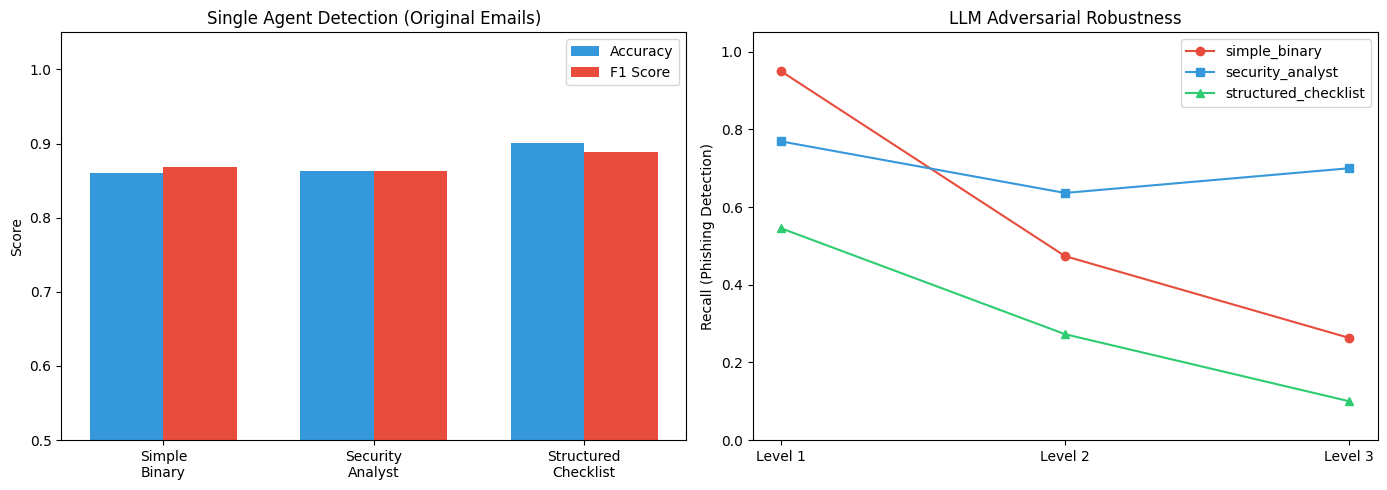

Chart saved to outputs/04_single_agent.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Test set comparison
styles = list(style_metrics.keys())
accs = [style_metrics[s]['accuracy'] for s in styles]
f1s = [style_metrics[s]['f1'] for s in styles]

x = range(len(styles))
w = 0.35
axes[0].bar([i - w/2 for i in x], accs, w, label='Accuracy', color='#3498db')
axes[0].bar([i + w/2 for i in x], f1s, w, label='F1 Score', color='#e74c3c')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Simple\nBinary', 'Security\nAnalyst', 'Structured\nChecklist'])
axes[0].set_ylabel('Score')
axes[0].set_title('Single Agent Detection (Original Emails)')
axes[0].legend()
axes[0].set_ylim(0.5, 1.05)

# Plot 2: Adversarial degradation
levels = ['Level 1', 'Level 2', 'Level 3']
for style_name, marker, color in [('simple_binary', 'o', '#e74c3c'), 
                                    ('security_analyst', 's', '#3498db'),
                                    ('structured_checklist', '^', '#2ecc71')]:
    recalls = [adv_results[style_name][l] for l in levels]
    axes[1].plot(levels, recalls, marker + '-', label=style_name, color=color)

axes[1].set_ylabel('Recall (Phishing Detection)')
axes[1].set_title('LLM Adversarial Robustness')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs/04_single_agent.png'), dpi=150)
plt.show()
print("Chart saved to outputs/04_single_agent.png")

In [8]:
print("=" * 50)
print("NOTEBOOK 4 COMPLETE - Single Agent Detection Summary")
print("=" * 50)
print("")
print("Model: Llama 3.1 8B (via Groq)")
print("")
print("Test Set Performance:")
print("  Simple Binary:        86.0% acc, 0.868 F1")
print("  Security Analyst:     86.3% acc, 0.863 F1")
print("  Structured Checklist: 90.1% acc, 0.889 F1")
print("")
print("KEY FINDING: LLMs are vulnerable to adversarial rewrites!")
print("  Simple Binary recall:        95% -> 26% (Level 3)")
print("  Security Analyst recall:     77% -> 70% (Level 3)")
print("  Structured Checklist recall: 55% -> 10% (Level 3)")
print("")
print("CONTRAST WITH ML BASELINE:")
print("  ML models (Notebook 3): recall INCREASED on rewrites")
print("  LLM agents (Notebook 4): recall COLLAPSED on rewrites")
print("  This shows ML is keyword-dependent, LLMs are semantic-dependent")
print("")
print("Files: outputs/04_single_agent.png")
print("")
print("Next: Notebook 5 - Multi-Agent Debate System")
print("  -> 6 specialist agents debate each email")
print("  -> This is YOUR main contribution")

NOTEBOOK 4 COMPLETE - Single Agent Detection Summary

Model: Llama 3.1 8B (via Groq)

Test Set Performance:
  Simple Binary:        86.0% acc, 0.868 F1
  Security Analyst:     86.3% acc, 0.863 F1
  Structured Checklist: 90.1% acc, 0.889 F1

KEY FINDING: LLMs are vulnerable to adversarial rewrites!
  Simple Binary recall:        95% -> 26% (Level 3)
  Security Analyst recall:     77% -> 70% (Level 3)
  Structured Checklist recall: 55% -> 10% (Level 3)

CONTRAST WITH ML BASELINE:
  ML models (Notebook 3): recall INCREASED on rewrites
  LLM agents (Notebook 4): recall COLLAPSED on rewrites
  This shows ML is keyword-dependent, LLMs are semantic-dependent

Files: outputs/04_single_agent.png

Next: Notebook 5 - Multi-Agent Debate System
  -> 6 specialist agents debate each email
  -> This is YOUR main contribution
